=== Theorem 3.5 numeric windows ===
L=1: (775, 2805.7000000000003)
L=2: (6591, 16531.300000000003)
L=3: None


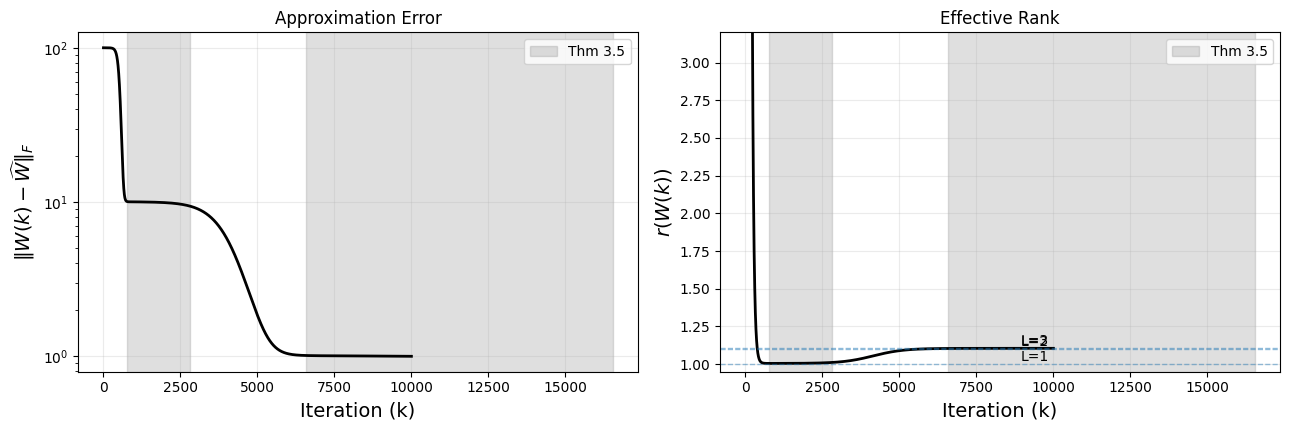

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict


# ============================================================
# 1. 基本工具
# ============================================================
def effective_rank_from_eigs(eigs: np.ndarray, eps: float = 1e-15) -> float:
    """
    r(W) = ||W||_* / ||W||
    對稱矩陣下奇異值 = |eigenvalues|
    """
    svals = np.abs(eigs)
    top = np.max(svals)
    if top < eps:
        return 0.0
    return float(np.sum(svals) / top)


def fro_error_to_ground_truth(current_eigs: np.ndarray, lambdas_hat: np.ndarray) -> float:
    """
    ||W(k) - W_hat||_F
    在共同 eigenbasis 下就是 eigenvalue 差的 Euclidean norm
    """
    return float(np.linalg.norm(current_eigs - lambdas_hat))


def all_rank_effective_ranks(lambdas_hat: np.ndarray, max_L: Optional[int] = None) -> np.ndarray:
    """
    一次算出 r(W_hat_1), r(W_hat_2), ..., r(W_hat_max_L)
    對 PSD spectrum:
        r(W_hat_L) = (lambda_1 + ... + lambda_L) / lambda_1
    """
    lambdas_hat = np.asarray(lambdas_hat, dtype=float)
    lambdas_hat = np.sort(lambdas_hat)[::-1]

    if max_L is None:
        max_L = len(lambdas_hat)
    else:
        max_L = min(max_L, len(lambdas_hat))

    if max_L <= 0:
        return np.array([], dtype=float)

    top = lambdas_hat[0]
    if top <= 1e-15:
        return np.zeros(max_L, dtype=float)

    return np.cumsum(lambdas_hat[:max_L]) / top


# ============================================================
# 2. PSD noisy spectrum
# ============================================================
def make_psd_noisy_spectrum(
    n: int = 200,
    leading=(100.0, 10.0, 1.0),
    tail_mode: str = "randexp",
    tail_scale: float = 0.06,
    seed: int = 7,
) -> np.ndarray:
    """
    建立 PSD noisy spectrum:
        前幾個主 eigenvalues 固定 + 小的正尾巴
    """
    rng = np.random.default_rng(seed)

    lambdas = np.zeros(n, dtype=float)
    m = len(leading)
    lambdas[:m] = np.array(leading, dtype=float)

    tail_len = n - m
    if tail_len > 0:
        idx = np.arange(1, tail_len + 1)

        if tail_mode == "exp":
            tail = tail_scale * np.exp(-idx / 18.0)
        elif tail_mode == "randexp":
            tail = tail_scale * np.exp(-idx / 18.0) * (0.7 + 0.6 * rng.random(tail_len))
        else:
            raise ValueError("tail_mode 必須是 'exp' 或 'randexp'")

        lambdas[m:] = tail

    lambdas = np.sort(lambdas)[::-1]
    return lambdas


# ============================================================
# 3. GD / GF scalar dynamics
# ============================================================
def gd_scalar_trajectory(
    lambda_val: float,
    alpha: float,
    eta: float,
    N: int,
    num_steps: int,
) -> np.ndarray:
    """
    離散遞迴:
        d(k+1) = d(k) - eta * d(k)^(N-1) * (d(k)^N - lambda)
    """
    d = float(alpha)
    hist = np.zeros(num_steps + 1, dtype=float)
    hist[0] = d

    for k in range(num_steps):
        d = d - eta * (d ** (N - 1)) * ((d ** N) - lambda_val)
        hist[k + 1] = d

    return hist


def gf_scalar_trajectory(
    lambda_val: float,
    alpha: float,
    N: int,
    t_max: float,
    dt: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    連續流:
        d'(t) = - d(t)^(N-1) * (d(t)^N - lambda)
    用顯式 Euler 做數值近似
    """
    num_steps = int(np.ceil(t_max / dt))
    ts = np.linspace(0.0, num_steps * dt, num_steps + 1)

    d = float(alpha)
    hist = np.zeros(num_steps + 1, dtype=float)
    hist[0] = d

    for j in range(num_steps):
        d = d + dt * (-(d ** (N - 1)) * ((d ** N) - lambda_val))
        hist[j + 1] = d

    return ts, hist


def simulate_gd_diagonal(
    lambdas_hat: np.ndarray,
    alpha: float = 5e-2,
    eta: float = 1e-4,
    num_steps: int = 10000,
    N: int = 2,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    同時模擬所有 eigen-directions 的 discrete dynamics
    """
    n = len(lambdas_hat)
    d_hist = np.zeros((num_steps + 1, n), dtype=float)
    w_eigs_hist = np.zeros((num_steps + 1, n), dtype=float)

    for i, lam in enumerate(lambdas_hat):
        d_i = gd_scalar_trajectory(lam, alpha=alpha, eta=eta, N=N, num_steps=num_steps)
        d_hist[:, i] = d_i
        w_eigs_hist[:, i] = d_i ** N

    return d_hist, w_eigs_hist


# ============================================================
# 4. theorem quantities: numerical T_Id and T_plus
# ============================================================
def T_Id_numeric(
    lambda_val: float,
    eps_root: float,
    alpha: float,
    eta: float,
    N: int,
    max_steps: int = 200000,
) -> Optional[int]:
    """
    數值版 T_N^{Id}(lambda, eps_root, alpha, eta)

    這裡 eps_root 是 theorem 裡第二個參數，單位在 root domain。
    我們抓最小 k 使得
        d_lambda(k) >= lambda^{1/N} - eps_root
    因為對 λ>0 且 identical initialization, d(k) 單調逼近 λ^{1/N}。
    """
    if lambda_val <= 0:
        raise ValueError("Theorem 3.5 這裡用的是 PSD / positive eigenvalues")

    target = lambda_val ** (1.0 / N) - eps_root
    if alpha >= target:
        return 0

    traj = gd_scalar_trajectory(
        lambda_val=lambda_val,
        alpha=alpha,
        eta=eta,
        N=N,
        num_steps=max_steps,
    )

    idx = np.where(traj >= target)[0]
    if len(idx) == 0:
        return None
    return int(idx[0])


def T_plus_numeric(
    lambda_val: float,
    threshold_root: float,
    alpha: float,
    N: int,
    t_max: float = 50.0,
    dt: float = 1e-5,
) -> Optional[float]:
    """
    數值版 T_N^+(lambda, threshold_root, alpha)

    抓 continuous flow 第一次到達 threshold_root 的時間 t
    """
    if alpha >= threshold_root:
        return 0.0

    ts, traj = gf_scalar_trajectory(
        lambda_val=lambda_val,
        alpha=alpha,
        N=N,
        t_max=t_max,
        dt=dt,
    )

    idx = np.where(traj >= threshold_root)[0]
    if len(idx) == 0:
        return None
    return float(ts[idx[0]])


def T_max_numeric(
    lambdas_hat: np.ndarray,
    L: int,
    eps: float,
    alpha: float,
    eta: float,
    N: int,
    max_steps: int = 200000,
) -> Optional[int]:
    """
    theorem 中
        T_max(L, eps, alpha, eta)
        = max_{ell in [L]} T_N^{Id}(lambda_ell, lambda_ell^{1/N} * eps / (4N), alpha, eta)
    """
    vals = []
    for ell in range(L):
        lam = float(lambdas_hat[ell])
        eps_root = (lam ** (1.0 / N)) * eps / (4.0 * N)
        t_id = T_Id_numeric(
            lambda_val=lam,
            eps_root=eps_root,
            alpha=alpha,
            eta=eta,
            N=N,
            max_steps=max_steps,
        )
        if t_id is None:
            return None
        vals.append(t_id)

    if len(vals) == 0:
        return None
    return int(max(vals))


def theorem35_window_numeric(
    lambdas_hat: np.ndarray,
    L: int,
    eps: float,
    eps_prime: float,
    alpha: float,
    eta: float,
    N: int,
    max_steps: int = 200000,
    t_max_plus: float = 50.0,
    dt_plus: float = 1e-5,
) -> Optional[Tuple[int, float]]:
    """
    依照 Theorem 3.5 的式子抓區間：

    lower =
      max{
        T_Id(lambda_1, lambda_1/2, alpha, eta),   <-- 注意這個要換成 root domain
        T_max(L, eps, alpha, eta)
      }

    upper =
      (1/eta) * T_plus(lambda_{L+1}, (eps' * lambda_{L+1})^{1/N}, alpha)

    關鍵注意：
    theorem 裡 T_Id 的第二個參數是 root-domain 的 beta，
    所以對 lambda_1/2 這件事要換成：
        beta = lambda_1^{1/N} - (lambda_1/2)^{1/N}
    這樣才對應到「d(k) 已至少達到 (lambda_1/2)^{1/N}」。
    """
    n = len(lambdas_hat)
    if not (1 <= L < n):
        raise ValueError("Theorem 3.5 需要 1 <= L < n，因為要用到 lambda_{L+1}")

    lambdas_hat = np.asarray(lambdas_hat, dtype=float)
    lambdas_hat = np.sort(lambdas_hat)[::-1]

    lam1 = float(lambdas_hat[0])
    lam_next = float(lambdas_hat[L])

    # 1) T_Id(lambda_1, lambda_1/2, alpha, eta) 對應的 root-domain beta
    beta_half = lam1 ** (1.0 / N) - (lam1 / 2.0) ** (1.0 / N)

    t_id_half = T_Id_numeric(
        lambda_val=lam1,
        eps_root=beta_half,
        alpha=alpha,
        eta=eta,
        N=N,
        max_steps=max_steps,
    )

    # 2) T_max(L, eps, alpha, eta)
    t_max_val = T_max_numeric(
        lambdas_hat=lambdas_hat,
        L=L,
        eps=eps,
        alpha=alpha,
        eta=eta,
        N=N,
        max_steps=max_steps,
    )

    if (t_id_half is None) or (t_max_val is None):
        return None

    lower = max(t_id_half, t_max_val)

    # 3) upper = (1/eta) T_plus(lambda_{L+1}, (eps' lambda_{L+1})^{1/N}, alpha)
    threshold_root = (eps_prime * lam_next) ** (1.0 / N)

    t_plus = T_plus_numeric(
        lambda_val=lam_next,
        threshold_root=threshold_root,
        alpha=alpha,
        N=N,
        t_max=t_max_plus,
        dt=dt_plus,
    )

    if t_plus is None:
        return None

    upper = t_plus / eta

    if lower > upper:
        return None

    return int(lower), int(np.floor(upper))


# ============================================================
# 5. curves
# ============================================================
def make_curves(
    w_eigs_hist: np.ndarray,
    lambdas_hat: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    左圖: ||W(k)-W_hat||_F
    右圖: r(W(k))
    """
    T = w_eigs_hist.shape[0] - 1
    approx_errors = np.zeros(T + 1, dtype=float)
    eff_ranks = np.zeros(T + 1, dtype=float)

    for k in range(T + 1):
        eigs_k = w_eigs_hist[k]
        approx_errors[k] = fro_error_to_ground_truth(eigs_k, lambdas_hat)
        eff_ranks[k] = effective_rank_from_eigs(eigs_k)

    return approx_errors, eff_ranks


# ============================================================
# 6. plotting
# ============================================================
def plot_rank_plateau_levels(ax, lambdas_hat: np.ndarray, x_last: float, max_show_L: int = 3):
    """
    在右圖畫 r(W_hat_L) 的參考平台線
    """
    levels = all_rank_effective_ranks(lambdas_hat, max_L=max_show_L)

    for i, level in enumerate(levels, start=1):
        ax.axhline(level, ls="--", lw=1, alpha=0.45)
        ax.text(
            x_last * 0.985,
            level,
            f"L={i}",
            fontsize=10,
            ha="right",
            va="bottom",
        )


def plot_with_theorem35_windows(
    ks: np.ndarray,
    approx_errors: np.ndarray,
    eff_ranks: np.ndarray,
    lambdas_hat: np.ndarray,
    windows: Dict[int, Optional[Tuple[int, float]]],
    max_show_L: int = 3,
    zoom_rank_ylim=(0.95, 3.2),
):
    """
    根據 theorem 3.5 windows 畫圖
    """
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
    ax1, ax2 = axes

    # shaded windows
    for L in range(1, max_show_L + 1):
        win = windows.get(L, None)
        if win is not None:
            a, b = win
            ax1.axvspan(a, b, alpha=0.25, color="gray", label="Thm 3.5" if L == 1 else None)
            ax2.axvspan(a, b, alpha=0.25, color="gray", label="Thm 3.5" if L == 1 else None)

    # left
    ax1.plot(ks, approx_errors, color="black", lw=2)
    ax1.set_yscale("log")
    ax1.set_title("Approximation Error")
    ax1.set_xlabel("Iteration (k)", fontsize=14)
    ax1.set_ylabel(r"$\|W(k)-\widehat{W}\|_F$", fontsize=14)
    ax1.grid(alpha=0.25)
    ax1.legend()

    # right
    ax2.plot(ks, eff_ranks, color="black", lw=2)
    plot_rank_plateau_levels(ax2, lambdas_hat, x_last=ks[-1], max_show_L=max_show_L)
    ax2.set_title("Effective Rank")
    ax2.set_xlabel("Iteration (k)", fontsize=14)
    ax2.set_ylabel(r"$r(W(k))$", fontsize=14)
    ax2.set_ylim(*zoom_rank_ylim)
    ax2.grid(alpha=0.25)
    ax2.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. main
# ============================================================
def main():
    # Figure 7-style parameters
    n = 200
    N = 2
    alpha = 5e-2
    eta = 1e-4
    num_steps = 10000

    # theorem parameters used in Figure 7 caption
    eps = 3e-2
    eps_prime = 6.4e-2

    # noisy PSD spectrum
    lambdas_hat = make_psd_noisy_spectrum(
        n=n,
        leading=(100.0, 10.0, 1.0),
        tail_mode="randexp",
        tail_scale=0.06,
        seed=7,
    )

    # simulate GD dynamics
    _, w_eigs_hist = simulate_gd_diagonal(
        lambdas_hat=lambdas_hat,
        alpha=alpha,
        eta=eta,
        num_steps=num_steps,
        N=N,
    )

    ks = np.arange(num_steps + 1)
    approx_errors, eff_ranks = make_curves(w_eigs_hist, lambdas_hat)

    # compute theorem 3.5 windows for L=1,2,3
    windows = {}
    for L in [1, 2, 3]:
        win = theorem35_window_numeric(
            lambdas_hat=lambdas_hat,
            L=L,
            eps=eps,
            eps_prime=eps_prime,
            alpha=alpha,
            eta=eta,
            N=N,
            max_steps=300000,
            t_max_plus=5.0,   # 因為 eta*num_steps = 1.0，抓寬一點保險
            dt_plus=1e-5,
        )
        windows[L] = win

    print("=== Theorem 3.5 numeric windows ===")
    for L, win in windows.items():
        print(f"L={L}: {win}")

    plot_with_theorem35_windows(
        ks=ks,
        approx_errors=approx_errors,
        eff_ranks=eff_ranks,
        lambdas_hat=lambdas_hat,
        windows=windows,
        max_show_L=3,
        zoom_rank_ylim=(0.95, 3.2),
    )


if __name__ == "__main__":
    main()